# Explainability Bias Visualization

**Figure List:**
1. Sentiment-difference heatmap (`sentiment_diff`, 5 models × 6 attributes) — showing that sentiment-level differences are minimal
2. "Saying one thing but scoring another" scatter plot (sentiment difference vs. horizontal mean-score difference) — the core figure
3. Semantic centroid-distance heatmap (`mean_centroid_dist`, 5 models × 6 attributes)

In [6]:
import glob
import re
import itertools
from pathlib import PurePath

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from textblob import TextBlob
from sentence_transformers import SentenceTransformer
from scipy.stats import mannwhitneyu
from IPython.display import display

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid', font_scale=1.05)

MODEL_COLORS = {
    'DeepSeek-V3.2':      '#4C72B0',
    'gemini-2.5-flash':   '#DD8452',
    'gpt-5-mini':         '#55A868',
    'grok-4-fast':        '#C44E52',
    'mistral-small-2603': '#8172B2',
}
MODELS_ORDER = ['DeepSeek-V3.2', 'gemini-2.5-flash', 'gpt-5-mini', 'grok-4-fast', 'mistral-small-2603']
GROUP_LABELS = {
    'gender':         'Gender',
    'age_group':      'Age Group',
    'nationality':    'Nationality',
    'religion':       'Religion',
    'marital_status': 'Marital Status',
    'volunteer_type': 'Volunteer Type',
}

In [ ]:
# ── 数据读取 ────────────────────────────────────────
csv_files = glob.glob(
    'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume/**/*evaluated_full.csv',
    recursive=True,
)
frames = []
for path in csv_files:
    basename = PurePath(path).name
    m = re.search(r'^(.*?_?[^_]+?)-Resume_sampled_50_with_Variants_evaluated_full\.csv$', basename)
    model_name = m.group(1) if m else PurePath(path).stem
    dfp = pd.read_csv(path)
    dfp['model'] = model_name
    frames.append(dfp)

all_df = pd.concat(frames, ignore_index=True)
if 'religion' in all_df.columns:
    all_df['religion'] = (
        all_df['religion'].astype('string').str.strip()
        .replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})
        .fillna('No religion')
    )
for c in ['technical_score','experience_score','stability_score','overall_score','screening_decision']:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

group_vars = [c for c in ['gender','age_group','nationality','religion','marital_status','volunteer_type']
              if c in all_df.columns]

# ── 计算情感得分 ─────────────────────────────────────────────────────────────
def calculate_sentiment(text):
    if pd.isna(text):
        return np.nan
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return np.nan

all_df['sentiment_score'] = all_df['reason'].apply(calculate_sentiment)

# ── 计算情感偏见指标 ──────────────────────────────────────────────────────────
def sentiment_bias_analysis(df, group_col):
    results = []
    for model in df['model'].unique():
        dm = df[df['model'] == model]
        sbg = dm.groupby(group_col)['sentiment_score'].agg(['mean','std','count']).dropna()
        if len(sbg) < 2:
            continue
        max_m, min_m = sbg['mean'].max(), sbg['mean'].min()
        diff = max_m - min_m
        ratio = min_m / max_m if max_m > 0 else np.nan
        groups = [dm[dm[group_col] == g]['sentiment_score'].dropna() for g in sbg.index]
        _, p_value = mannwhitneyu(groups[0], groups[1], alternative='two-sided') if len(groups) >= 2 else (None, np.nan)
        results.append({'model': model, 'group_col': group_col,
                        'sentiment_diff': diff, 'p_value': p_value})
    return pd.DataFrame(results)

sentiment_df = pd.concat([sentiment_bias_analysis(all_df, g) for g in group_vars], ignore_index=True)

# ── 计算水平偏见均分差（用于对比）────────────────────────────────────────────
def group_mean_diff(df, score_col, group_col):
    grp = df.groupby(group_col)[score_col].mean().dropna()
    return float(grp.max() - grp.min()) if len(grp) >= 2 else 0.0

horizontal_rows = []
for model_name, sub in all_df.groupby('model'):
    for gc in group_vars:
        horizontal_rows.append({
            'model': model_name, 'group_col': gc,
            'mean_score_diff': group_mean_diff(sub, 'overall_score', gc),
        })
horizontal_df = pd.DataFrame(horizontal_rows)

# ── 合并两个数据集 ────────────────────────────────────────────────────────────
compare_df = pd.merge(sentiment_df, horizontal_df, on=['model', 'group_col'])
print('Data preparation complete, total records:', len(compare_df))

Data preparation complete, total records: 30


## Figure 1: Sentiment-Difference Heatmap

This figure shows the sentiment-score difference (`sentiment_diff`) of five models across six sensitive attributes.
Very small values indicate that the sentiment tendency in explanations is almost the same across groups.
Cells with significant p-values (`p < 0.05`) are marked with an asterisk.

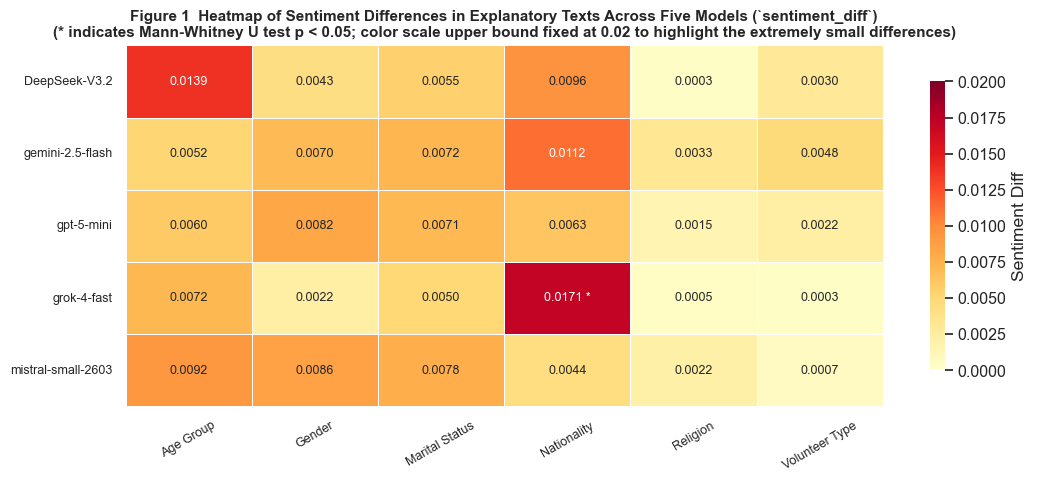

Saved: exp_fig1_sentiment_heatmap.png


In [8]:
pivot_sent = sentiment_df.pivot(index='model', columns='group_col', values='sentiment_diff')
pivot_sent = pivot_sent.reindex(index=MODELS_ORDER)
pivot_sent.columns = [GROUP_LABELS.get(c, c) for c in pivot_sent.columns]

pivot_p = sentiment_df.pivot(index='model', columns='group_col', values='p_value')
pivot_p = pivot_p.reindex(index=MODELS_ORDER)
pivot_p.columns = [GROUP_LABELS.get(c, c) for c in pivot_p.columns]

# 生成标注文字：数值 + 显著性星号
annot = pivot_sent.copy().astype(str)
for row in pivot_sent.index:
    for col in pivot_sent.columns:
        val = pivot_sent.loc[row, col]
        p   = pivot_p.loc[row, col]
        star = ' *' if (not np.isnan(p) and p < 0.05) else ''
        annot.loc[row, col] = f'{val:.4f}{star}'

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    pivot_sent, ax=ax,
    annot=annot, fmt='', annot_kws={'size': 9},
    cmap='YlOrRd',
    vmin=0, vmax=0.02,   # 固定上限0.02，突出数值的极小性
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Sentiment Diff'},
)
ax.set_title('Figure 1  Heatmap of Sentiment Differences in Explanatory Texts Across Five Models (`sentiment_diff`)\n'
             '(* indicates Mann-Whitney U test p < 0.05; color scale upper bound fixed at 0.02 to highlight the extremely small differences)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig('exp_fig1_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp_fig1_sentiment_heatmap.png')

## Figure 2: "Saying One Thing but Scoring Another" Scatter Plot

X-axis = sentiment difference (`sentiment_diff`); larger values indicate less equal sentiment in explanatory texts.
Y-axis = horizontal mean-score difference (`mean_score_diff`); larger values indicate more unfair actual scoring.
Each point represents one model × group combination, and color indicates the model.

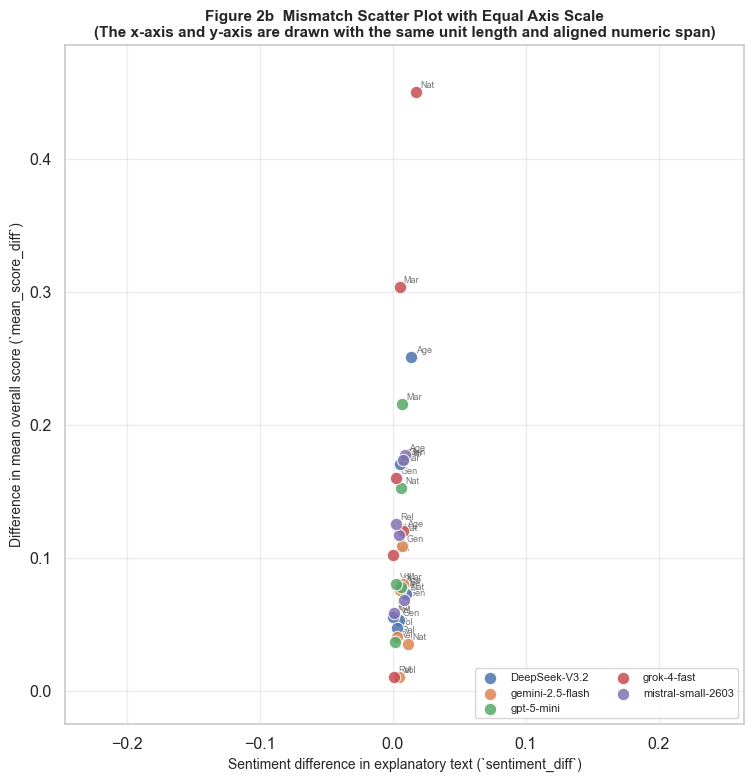

Saved: exp_fig2_mismatch_scatter_equal_axes.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

for model in MODELS_ORDER:
    sub = compare_df[compare_df['model'] == model]
    color = MODEL_COLORS.get(model, '#888')
    ax.scatter(
        sub['sentiment_diff'], sub['mean_score_diff'],
        color=color, s=80, alpha=0.85,
        edgecolors='white', linewidth=0.8,
        label=model, zorder=5
    )

for _, row in compare_df.iterrows():
    ax.annotate(
        GROUP_LABELS.get(row['group_col'], row['group_col'])[:3],
        xy=(row['sentiment_diff'], row['mean_score_diff']),
        xytext=(3, 3), textcoords='offset points',
        fontsize=6.5, color='#555', alpha=0.8
    )

x = compare_df['sentiment_diff']
y = compare_df['mean_score_diff']

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

x_pad = max((x_max - x_min) * 0.08, 0.0005)
y_pad = max((y_max - y_min) * 0.08, 0.02)

x_min, x_max = x_min - x_pad, x_max + x_pad
y_min, y_max = y_min - y_pad, y_max + y_pad

span = max(x_max - x_min, y_max - y_min)
x_center = (x_min + x_max) / 2
y_center = (y_min + y_max) / 2

ax.set_xlim(x_center - span / 2, x_center + span / 2)
ax.set_ylim(y_center - span / 2, y_center + span / 2)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('Sentiment difference in explanatory text (`sentiment_diff`)', fontsize=10)
ax.set_ylabel('Difference in mean overall score (`mean_score_diff`)', fontsize=10)
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.grid(alpha=0.35)
ax.set_title('Figure 2b  Mismatch Scatter Plot with Equal Axis Scale\n'
             '(The x-axis and y-axis are drawn with the same unit length and aligned numeric span)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_fig2_mismatch_scatter_equal_axes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp_fig2_mismatch_scatter_equal_axes.png')

## Figure 2c: Side-by-Side Comparison of the Two Scatter Plots

This figure places the original mismatch scatter plot and the equal-axis version side by side
to make their visual differences directly comparable.

## Figure 3: Semantic Centroid-Distance Heatmap

This figure shows the mean pairwise centroid distance (`mean_centroid_dist`) of five models across six sensitive attributes.

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8858.32it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


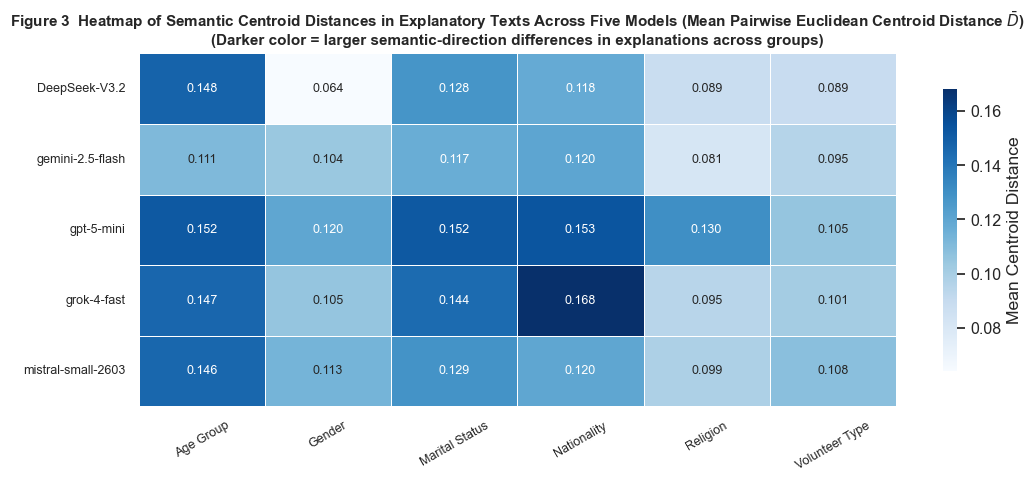

Saved: exp_fig3_semantic_heatmap.png


In [10]:
# ── 重新计算语义向量指标（与原 notebook 完全一致）────────────────────────────
model_sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
all_df['reason_vector'] = all_df['reason'].apply(
    lambda x: model_sbert.encode(str(x)) if pd.notna(x) else np.nan
)

def semantic_bias_analysis(df, group_col):
    results = []
    for model in df['model'].unique():
        dm = df[df['model'] == model].dropna(subset=['reason_vector'])
        if len(dm) < 2:
            continue
        vbg = dm.groupby(group_col)['reason_vector'].apply(np.stack).to_dict()
        gnames = list(vbg.keys())
        if len(gnames) < 2:
            continue
        centroids = {g: np.mean(v, axis=0) for g, v in vbg.items()}
        pairwise = [np.linalg.norm(centroids[a] - centroids[b])
                    for a, b in itertools.combinations(gnames, 2)]
        results.append({
            'model': model, 'group_col': group_col,
            'mean_centroid_dist': float(np.mean(pairwise)),
        })
    return pd.DataFrame(results)

semantic_df = pd.concat([semantic_bias_analysis(all_df, g) for g in group_vars], ignore_index=True)

pivot_sem = semantic_df.pivot(index='model', columns='group_col', values='mean_centroid_dist')
pivot_sem = pivot_sem.reindex(index=MODELS_ORDER)
pivot_sem.columns = [GROUP_LABELS.get(c, c) for c in pivot_sem.columns]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    pivot_sem, ax=ax,
    annot=True, fmt='.3f', annot_kws={'size': 9},
    cmap='Blues',
    vmin=pivot_sem.values.min(), vmax=pivot_sem.values.max(),
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Mean Centroid Distance'},
)
ax.set_title('Figure 3  Heatmap of Semantic Centroid Distances in Explanatory Texts Across Five Models (Mean Pairwise Euclidean Centroid Distance $\\bar{D}$)\n'
             '(Darker color = larger semantic-direction differences in explanations across groups)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig('exp_fig3_semantic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp_fig3_semantic_heatmap.png')